# Notebook 05a — RoBERTa Fine-Tuning

## RoBERTa Model Setup

This section loads the required libraries and configuration settings for transformer-based modelling. It prepares the environment for training and evaluation by importing dependencies for data processing, tokenisation, model definition, optimisation, and performance assessment.

Output directories for saving checkpoints, predictions, and plots are also created. The computation device is then selected automatically, giving priority to Apple MPS, followed by CUDA, and finally CPU, depending on hardware availability.

In [1]:
# System path setup
import sys, os, pickle, time, copy
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformers utilities
from transformers import (
    AutoTokenizer, AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

import warnings; warnings.filterwarnings('ignore')

# Configuration
import config
from config import (
    LABELLED_DATASET,
    PLOTS_DIR,
    ROBERTA_DIR,
    ROBERTA_MODEL_ID,
    ROBERTA_PREDS_PKL,
    ROBERTA_RESULTS_CSV,
    NUM_LABELS,
    MAX_LENGTH,
    BATCH_SIZE,
    NUM_EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_RATIO,
    EARLY_STOPPING_PATIENCE,
    ID2LABEL,
)

# Create output directories
os.makedirs(PLOTS_DIR / 'roberta_model', exist_ok=True)
os.makedirs(ROBERTA_DIR, exist_ok=True)

# Select device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

/Users/latikasisodiya/Documents/PROJECTS/depression_detection_nlp_project/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## Data Loading and Splitting

The dataset is loaded and divided into training, validation, and test sets using the predefined `split` column. Indices are reset to ensure clean and consistent data handling during batching and model training.

The sizes of each split are displayed to verify correct partitioning.

In [2]:
# Load dataset
df = pd.read_csv(LABELLED_DATASET)

# Split dataset
train = df[df['split'] == 'train'].reset_index(drop=True)
val   = df[df['split'] == 'val'].reset_index(drop=True)
test  = df[df['split'] == 'test'].reset_index(drop=True)

# Print dataset sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 3,996  Val: 3,996  Test: 1,998


## Tokenisation

The pre-trained tokenizer corresponding to the selected RoBERTa model is loaded. It converts raw text into token IDs that can be processed by the transformer.

Dynamic padding is applied using a data collator to ensure efficient batching. A sample sentence is tokenised to inspect how text is converted into tokens.

In [3]:
# Load tokenizer and data collator
tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_ID)
collator  = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')

# Display vocabulary size
print(f'Vocab size: {tokenizer.vocab_size:,}')

Vocab size: 50,265


## Custom Dataset

A custom PyTorch dataset is defined to efficiently prepare inputs for the transformer model. All text samples are tokenised once during initialisation, avoiding repeated tokenisation during training and improving performance.

The dataset returns input IDs, attention masks, and labels for each sample. Optionally, an additional linguistic feature (`intensifier_score`) can be included to extend the input representation.

In [4]:
class SuicideDataset(Dataset):
    def __init__(self, df, tokenizer, text_col='text_clean',
                 label_col='label_id', max_length=128, use_intensifier=False):

        # Tokenise all texts
        texts = df[text_col].fillna('').tolist()
        encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
            return_tensors=None,
        )

        self.input_ids      = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels         = df[label_col].tolist()

        # Optional linguistic feature
        self.intensifier = (
            df['intensifier_score'].fillna(0).tolist()
            if use_intensifier and 'intensifier_score' in df.columns else None
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         self.labels[idx],
        }

        if self.intensifier is not None:
            item['intensifier'] = self.intensifier[idx]

        return item

## Model Architecture

A custom classification model is built on top of a pre-trained RoBERTa encoder. The contextual representation of the `[CLS]` token is used as the primary input for classification.

An optional linguistic feature (`intensifier_score`) can be concatenated with the `[CLS]` embedding to enrich the representation. The combined features are passed through a feedforward classifier with dropout and GELU activation for robust prediction.

In [5]:
class RoBERTaClassifier(nn.Module):
    def __init__(self, model_id, num_labels=2, use_linguistic=False, dropout=0.1):
        super().__init__()

        # Load pretrained encoder
        self.encoder = AutoModel.from_pretrained(model_id)
        hidden = self.encoder.config.hidden_size

        self.use_linguistic = use_linguistic
        in_dim = hidden + 1 if use_linguistic else hidden

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(self, input_ids, attention_mask, intensifier=None):
        # Encode input text
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # Extract [CLS] representation
        pooled = out.last_hidden_state[:, 0, :]

        # Concatenate linguistic feature if enabled
        if self.use_linguistic and intensifier is not None:
            pooled = torch.cat([pooled, intensifier.unsqueeze(1)], dim=1)

        return self.classifier(pooled)

## Training and Evaluation

These functions define the training and evaluation pipeline for the transformer model. The training function performs forward and backward passes, applies gradient clipping, and updates model parameters using the optimizer and scheduler.

The evaluation function runs the model in inference mode and computes key performance metrics, including accuracy, precision, recall, F1-score, and ROC-AUC. It also stores predictions and probabilities for further analysis.

In [6]:
# Train model for one epoch
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for batch in loader:
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)

        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)

        optimizer.zero_grad()

        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss    += loss.item() * len(labs)
        total_correct += (logits.argmax(1) == labs).sum().item()
        total         += len(labs)

    return total_loss / total, total_correct / total


# Evaluate model
@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):

    model.eval()
    total_loss = 0

    all_preds, all_labels, all_probs = [], [], []

    for batch in loader:
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)

        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)

        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)

        probs = torch.softmax(logits, 1)[:, 1]

        total_loss += loss.item() * len(labs)

        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(labs.cpu())
        all_probs.append(probs.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs  = torch.cat(all_probs).numpy()

    return {
        'loss' : total_loss / len(loader.dataset),
        'accuracy' : accuracy_score(all_labels, all_preds),
        'f1' : f1_score(all_labels, all_preds, pos_label=1),
        'recall' : recall_score(all_labels, all_preds, pos_label=1),
        'precision' : precision_score(all_labels, all_preds, pos_label=1),
        'roc_auc' : roc_auc_score(all_labels, all_probs),
        'preds' : all_preds.tolist(),
        'labels' : all_labels.tolist(),
        'probs' : all_probs.tolist(),
    }

## Experiment Pipeline

This function defines the complete training pipeline for running different experimental configurations. It handles dataset preparation, tokenisation, dataloader creation, model initialisation, optimisation setup, and training.

Early stopping is applied based on validation F1-score to prevent overfitting. The best model checkpoint is saved and reloaded for final evaluation. Training history and performance metrics are returned for further analysis and comparison across experiments.

In [7]:
_base_state = None  # cached after first experiment


def run_experiment(text_col, use_intensifier, experiment_name):
    global _base_state

    print(f"\n{'='*60}\nExperiment : {experiment_name}\n{'='*60}")

    # Pre-tokenise dataset
    print('  Tokenising...', end=' ', flush=True)
    t0 = time.time()

    train_ds = SuicideDataset(
        train, tokenizer, text_col=text_col,
        max_length=MAX_LENGTH, use_intensifier=use_intensifier
    )

    val_ds = SuicideDataset(
        val, tokenizer, text_col=text_col,
        max_length=MAX_LENGTH, use_intensifier=use_intensifier
    )

    print(f'done in {time.time()-t0:.1f}s')


    # DataLoaders
    n_workers = 0
    use_pin   = (DEVICE.type == 'cuda')

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=n_workers,
        pin_memory=use_pin,
        collate_fn=collator
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=n_workers,
        pin_memory=use_pin,
        collate_fn=collator
    )


    # Model initialisation
    model = RoBERTaClassifier(
        ROBERTA_MODEL_ID,
        num_labels=NUM_LABELS,
        use_linguistic=use_intensifier
    ).to(DEVICE)

    # Reset encoder weights for fair comparison
    if _base_state is None:
        _base_state = copy.deepcopy(model.encoder.state_dict())
    else:
        model.encoder.load_state_dict(_base_state)


    # Optimisation setup
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    total_steps = len(train_loader) * NUM_EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps
    )

    criterion = nn.CrossEntropyLoss()


    # Training loop with early stopping
    ckpt = os.path.join(
        ROBERTA_DIR,
        f'best_{experiment_name.replace(" ","_")}.pt'
    )

    history, best_f1, patience = [], 0, 0

    for epoch in range(1, NUM_EPOCHS + 1):

        t0 = time.time()

        tl, ta = train_epoch(
            model, train_loader, optimizer, scheduler, criterion, DEVICE
        )

        vm = evaluate_epoch(model, val_loader, criterion, DEVICE)

        history.append({
            'epoch': epoch,
            'train_loss': tl,
            'train_acc': ta,
            **{f'val_{k}': v for k, v in vm.items()
               if k not in ('preds','labels','probs')}
        })

        print(
            f'  Epoch {epoch}/{NUM_EPOCHS}  loss={tl:.4f}  '
            f'val_f1={vm["f1"]:.4f}  recall={vm["recall"]:.4f}  '
            f'({time.time()-t0:.0f}s)'
        )

        # Save best model
        if vm['f1'] > best_f1:
            best_f1 = vm['f1']
            torch.save(model.state_dict(), ckpt)
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print(f'  Early stopping at epoch {epoch}.')
                break


    # Load best checkpoint
    model.load_state_dict(
        torch.load(ckpt, map_location=DEVICE, weights_only=True)
    )

    final_val = evaluate_epoch(model, val_loader, criterion, DEVICE)

    return model, pd.DataFrame(history), final_val, experiment_name

## RoBERTa Baseline Experiment

The baseline experiment is executed using only the cleaned text as input. No additional linguistic features are included, allowing the model to learn purely from contextual embeddings.

This serves as a reference point to evaluate the impact of incorporating additional features in subsequent experiments.

In [8]:
# Run baseline experiment
model_base, hist_base, val_base, name_base = run_experiment(
    'text_clean',
    use_intensifier=False,
    experiment_name='RoBERTa Baseline'
)


Experiment : RoBERTa Baseline
  Tokenising... done in 0.5s


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9005.66it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.3356  val_f1=0.9652  recall=0.9727  (264s)
  Epoch 2/3  loss=0.0973  val_f1=0.9699  recall=0.9763  (304s)
  Epoch 3/3  loss=0.0431  val_f1=0.9681  recall=0.9823  (314s)


## RoBERTa with Negation Handling

This experiment uses text where negations are explicitly marked (e.g., `_NEG`), allowing the model to better capture the impact of negation on meaning.

No additional linguistic features are included, enabling evaluation of how negation-aware preprocessing alone affects performance compared to the baseline.

In [9]:
# Run negation-aware experiment
model_neg, hist_neg, val_neg, name_neg = run_experiment(
    'text_neg_tagged',
    use_intensifier=False,
    experiment_name='RoBERTa + Negation'
)


Experiment : RoBERTa + Negation
  Tokenising... done in 0.6s


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6213.13it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.3152  val_f1=0.9607  recall=0.9328  (336s)
  Epoch 2/3  loss=0.1035  val_f1=0.9719  recall=0.9626  (340s)
  Epoch 3/3  loss=0.0344  val_f1=0.9759  recall=0.9737  (337s)


## RoBERTa with Negation and Intensifier

This experiment extends the negation-aware setup by incorporating an additional linguistic feature (`intensifier_score`). The feature is concatenated with the contextual representation to provide extra signal about emphasis in the text.

This configuration evaluates whether combining negation handling with linguistic cues improves model performance over previous setups.

In [10]:
# Run full feature experiment
model_full, hist_full, val_full, name_full = run_experiment(
    'text_neg_tagged',
    use_intensifier=True,
    experiment_name='RoBERTa + Negation + Intensifier'
)


Experiment : RoBERTa + Negation + Intensifier
  Tokenising... done in 0.8s


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6607.42it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.3306  val_f1=0.9658  recall=0.9621  (353s)
  Epoch 2/3  loss=0.1059  val_f1=0.9709  recall=0.9692  (362s)
  Epoch 3/3  loss=0.0427  val_f1=0.9715  recall=0.9742  (354s)


## Training Curves

Training loss and validation F1-score are plotted across epochs for all experiment variants. These curves help analyse convergence behaviour and compare how each configuration performs during training.

The visualisation provides insight into model stability, learning progression, and potential overfitting.

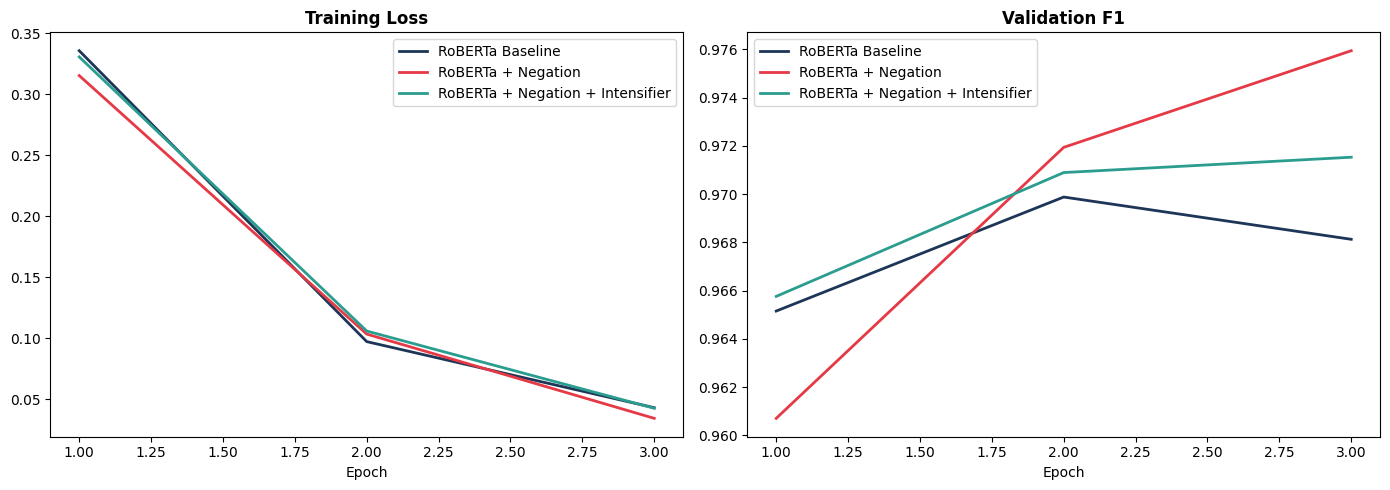

In [11]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1D3557', '#E63946', '#2A9D8F']

for hist, name, c in zip(
    [hist_base, hist_neg, hist_full],
    [name_base, name_neg, name_full],
    colors
):
    axes[0].plot(hist['epoch'], hist['train_loss'],
                 label=name, color=c, linewidth=2)

    axes[1].plot(hist['epoch'], hist['val_f1'],
                 label=name, color=c, linewidth=2)


# Configure plots
for ax, title in zip(axes, ['Training Loss', 'Validation F1']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'roberta_model' / 'training_curves.png',
            bbox_inches='tight')
plt.show()

## Ablation Study

The performance of different model configurations is summarised to analyse the impact of each component. This includes the baseline model, negation-aware preprocessing, and the addition of linguistic features.

The comparison highlights how each modification contributes to overall performance across key evaluation metrics.

In [12]:
# Prepare ablation results
ablation_rows = []

for name, m in [
    (name_base, val_base),
    (name_neg,  val_neg),
    (name_full, val_full)
]:
    ablation_rows.append({
        'Experiment': name,
        'Accuracy':  round(m['accuracy'],  4),
        'Precision': round(m['precision'], 4),
        'Recall':    round(m['recall'],    4),
        'F1':        round(m['f1'],        4),
        'ROC-AUC':   round(m['roc_auc'],   4),
    })

ablation_df = pd.DataFrame(ablation_rows)

# Display results
print(ablation_df.to_string(index=False))

                      Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
                RoBERTa Baseline    0.9700     0.9636  0.9763 0.9699   0.9969
              RoBERTa + Negation    0.9762     0.9782  0.9737 0.9759   0.9961
RoBERTa + Negation + Intensifier    0.9717     0.9688  0.9742 0.9715   0.9967


## Confusion Matrices

Confusion matrices are visualised for each experiment to examine prediction behaviour across classes. They provide a detailed view of true positives, false positives, true negatives, and false negatives.

This helps identify class-wise performance differences and understand where the model makes errors.

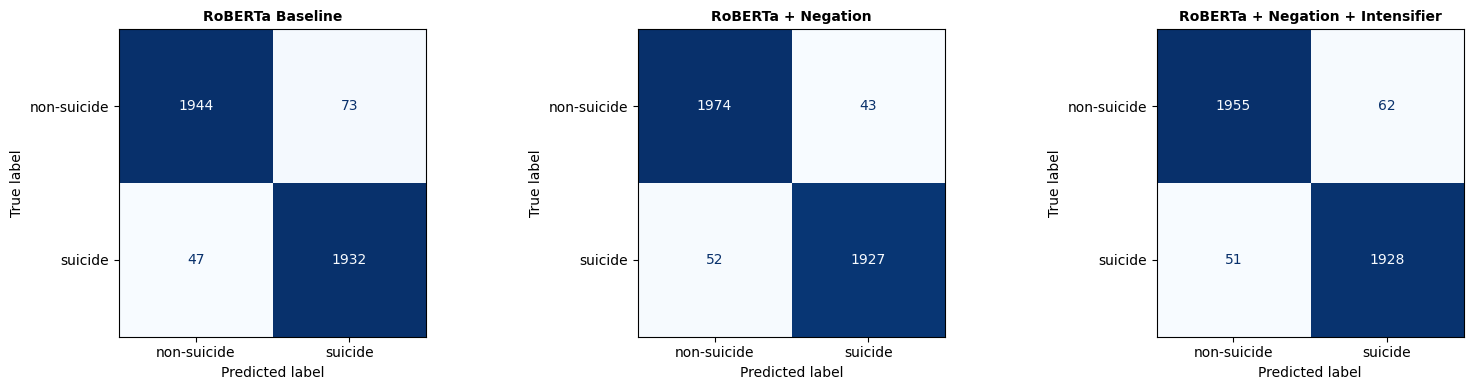

In [13]:
# Plot confusion matrices for all experiments
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, m in zip(
    axes,
    [name_base, name_neg, name_full],
    [val_base,  val_neg,  val_full]
):
    ConfusionMatrixDisplay(
        confusion_matrix(m['labels'], m['preds']),
        display_labels=['non-suicide', 'suicide']
    ).plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(name, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'roberta_model' / 'ablation_cm.png',
            bbox_inches='tight')
plt.show()

## Best Model Selection and Test Evaluation

The best-performing configuration is selected based on validation F1-score. The corresponding model setup is then used to evaluate performance on the test set.

This provides an unbiased estimate of how well the final model generalises to unseen data, along with a detailed classification report.

In [14]:
# Select best experiment based on F1
best_idx       = ablation_df['F1'].idxmax()
best_condition = ablation_df.loc[best_idx, 'Experiment']

print(f'Best condition: {best_condition}')


# Map experiment to model configuration
best_map = {
    name_base: (model_base, 'text_clean',      False),
    name_neg:  (model_neg,  'text_neg_tagged', False),
    name_full: (model_full, 'text_neg_tagged', True),
}

best_model, best_col, best_intens = best_map[best_condition]


# Prepare test dataset
test_ds = SuicideDataset(
    test,
    tokenizer,
    text_col=best_col,
    max_length=MAX_LENGTH,
    use_intensifier=best_intens
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE * 2,
    collate_fn=collator
)


# Evaluate on test set
test_metrics = evaluate_epoch(
    best_model,
    test_loader,
    nn.CrossEntropyLoss(),
    DEVICE
)


# Print classification report
print(classification_report(
    test_metrics['labels'],
    test_metrics['preds'],
    target_names=['non-suicide', 'suicide']
))

Best condition: RoBERTa + Negation
              precision    recall  f1-score   support

 non-suicide       0.98      0.98      0.98      1008
     suicide       0.98      0.98      0.98       990

    accuracy                           0.98      1998
   macro avg       0.98      0.98      0.98      1998
weighted avg       0.98      0.98      0.98      1998



## Saving Results

The final predictions, evaluation metrics, and ablation results are saved for reproducibility and further analysis. This includes test predictions, probabilities, and the best-performing configuration.

The outputs are stored as a pickle file and a CSV file for easy reuse and reporting.

In [15]:
# Save predictions and results
roberta_preds = {
    'ablation': ablation_df,
    'test_preds':  test_metrics['preds'],
    'test_labels': test_metrics['labels'],
    'test_probs':  test_metrics['probs'],
    'best_condition': best_condition,
}

with open(ROBERTA_PREDS_PKL, 'wb') as f:
    pickle.dump(roberta_preds, f)


# Save ablation results
ablation_df.to_csv(ROBERTA_RESULTS_CSV, index=False)